In [1]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS, get_trained_agent
from sac.trainer import HockeyTrainer, SCORE_REWARD, DEFAULT_REWARD, ACTION_BOUNDS, SCALING
from sac.tournament import PooledTournament

In [2]:
params = SB3_PARAMS
hidden_sizes = [256, 256]
params["alpha"] = 0.003
params["lr"] = 3e-4
params["hidden_sizes"] = hidden_sizes
params["action_bounds"] = ACTION_BOUNDS
params["obs_scale"] = SCALING

In [3]:
random_seed = 0

In [4]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [5]:
filepath = f"./results/adaptive4-{random_seed}"

In [6]:
agent = from_dict(**params)
trainer = HockeyTrainer(agent, reward_func=DEFAULT_REWARD)
weak_opponent = h_env.BasicOpponent(weak=True)
strong_opponent = h_env.BasicOpponent(weak=False)

In [7]:
trainer.load("./agents/adaptive-0", episode=1500)

In [8]:
tournament = PooledTournament(seed=random_seed)
tournament.add_agent(weak_opponent)
tournament.add_agent(strong_opponent)

In [ ]:
agent_paths = [
    # "./agents/reward-0-5000.pth",
    # "./agents/continue-0-10000.pth",
    # "./agents/selfplay-0-5000.pth",
    # "./agents/strong-0-7000.pth",
    # "./agents/strongcont-0-5000.pth",
    # "./agents/strongcont-0-5500.pth",
    "./agents/adaptive-0-10000.pth",
    "./agents/adaptive2-0-2000.pth",
    "./agents/adaptive3-0-2500.pth"
]
# tournament.add_agent(weak_opponent)
# tournament.add_agent(strong_opponent)
for agent_path in agent_paths:
    new_agent = get_trained_agent(agent_path)
    tournament.add_agent(new_agent)

In [11]:
trainer.warmup(10000)

In [12]:
max_timesteps = 500
new_episodes = 500
log_interval = 20
train_interval = 10

In [13]:
def evaluate_agent(trainer, opponent, n=100):
    rewards, scores = trainer.evaluate(opponent, n, render=False)
    print("Avg reward:",np.mean(rewards))
    print("Winrate:",0.5 * (np.mean(scores)+1))
    print("Winrate (no ties):", np.mean(np.asarray(scores) == 1))

In [14]:
def add_agent(trainer, tournament, params):
    # new_agent = trainer.create_agent(params)
    new_agent = from_dict(**params)
    agent_state = trainer.agent.state()
    new_agent.restore_state(agent_state)
    tournament.add_agent(new_agent)

In [15]:
for i in range(20):
    trainer.train(tournament, new_episodes, train_interval, log_interval, max_timesteps)
    evaluate_agent(trainer, weak_opponent)
    evaluate_agent(trainer, strong_opponent)
    trainer.save_agent(filepath)
    add_agent(trainer, tournament, params)

    20: Reward:   -5.053 Winrate:    0.325
    40: Reward:   -1.899 Winrate:    0.475
    60: Reward:    0.747 Winrate:    0.600
    80: Reward:   -0.321 Winrate:    0.575
   100: Reward:   -0.385 Winrate:    0.575
   120: Reward:    0.074 Winrate:    0.600
   140: Reward:    0.053 Winrate:    0.575
   160: Reward:   -3.216 Winrate:    0.400
   180: Reward:   -4.573 Winrate:    0.425
   200: Reward:   -0.482 Winrate:    0.525
   220: Reward:   -4.183 Winrate:    0.375
   240: Reward:   -1.508 Winrate:    0.500
   260: Reward:    0.495 Winrate:    0.600
   280: Reward:   -6.054 Winrate:    0.275
   300: Reward:   -4.586 Winrate:    0.350
   320: Reward:    0.790 Winrate:    0.625
   340: Reward:   -1.528 Winrate:    0.525
   360: Reward:   -2.944 Winrate:    0.475
   380: Reward:   -4.362 Winrate:    0.450
   400: Reward:   -2.604 Winrate:    0.525
   420: Reward:   -0.382 Winrate:    0.600
   440: Reward:   -1.590 Winrate:    0.525
   460: Reward:    2.385 Winrate:    0.725
   480: Rew

KeyboardInterrupt: 

In [15]:
trainer.evaluate(weak_opponent, render=True)

([-10, -10, -10, 10, -10], [-1, -1, -1, 1, -1])

In [16]:
trainer.evaluate(strong_opponent, render=True)

([7.473680503458752,
  9.66813170478957,
  8.933344866383347,
  -15.700173348135603,
  10.0],
 [1, 1, 1, -1, 1])

In [16]:
trainer.reset()

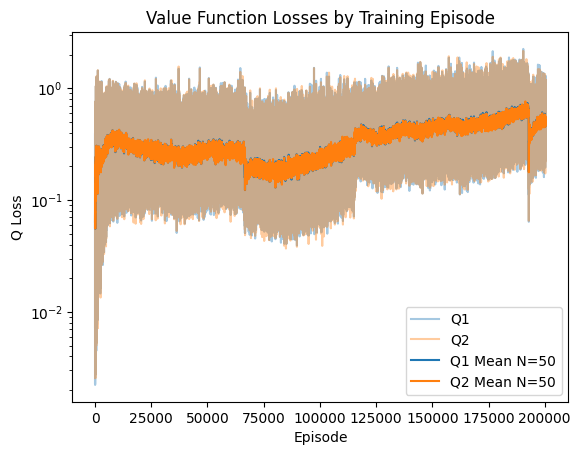

In [15]:
q_losses = np.stack([trainer.logs["Q1_loss"], trainer.logs["Q2_loss"]]).T
plot_q(q_losses, "./results")

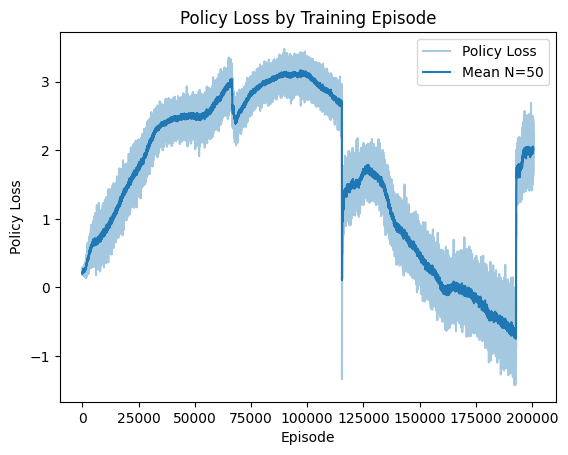

In [16]:
plot_policy_loss(trainer.logs["Policy_loss"], "./results")

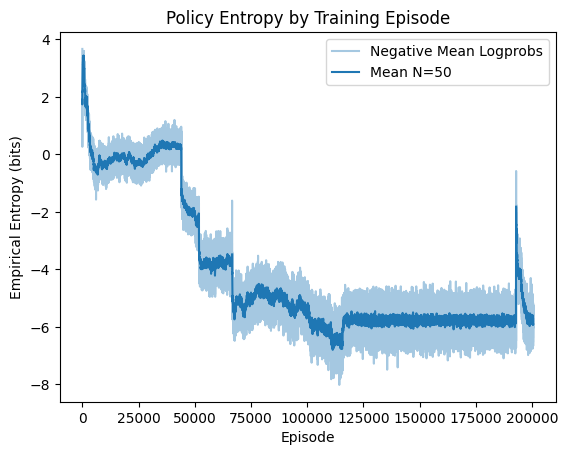

In [17]:
plot_entropy(np.asarray(trainer.logs["Logprobs"]), "./results")

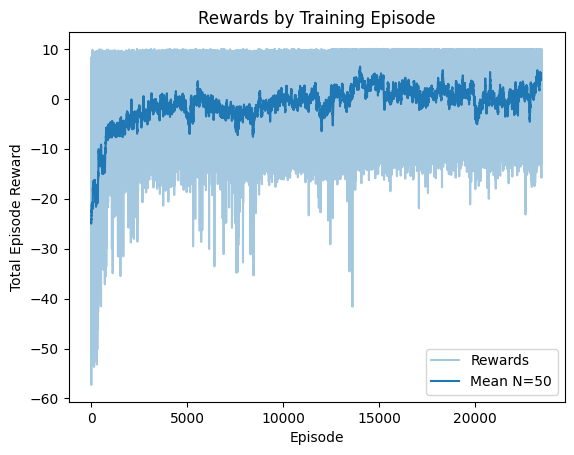

In [18]:
plot_rewards(trainer.logs["Rewards"], "./results")

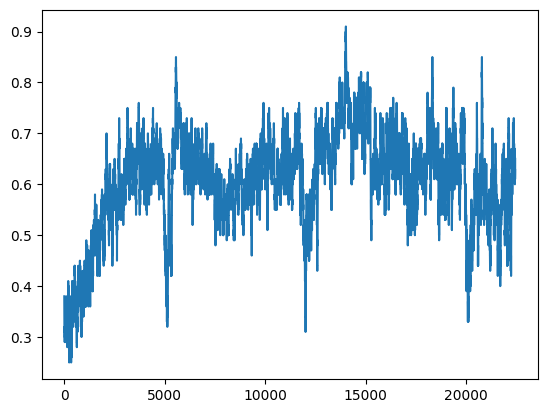

In [22]:
plt.plot(running_mean(0.5*(np.asarray(trainer.logs["Scores"])+1), 50))

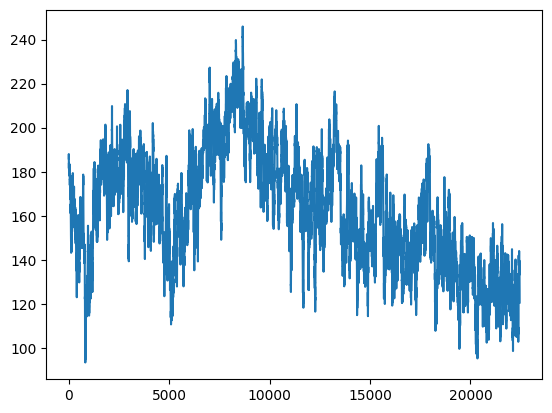

In [23]:
plt.plot(running_mean(trainer.logs["Lengths"], 50))

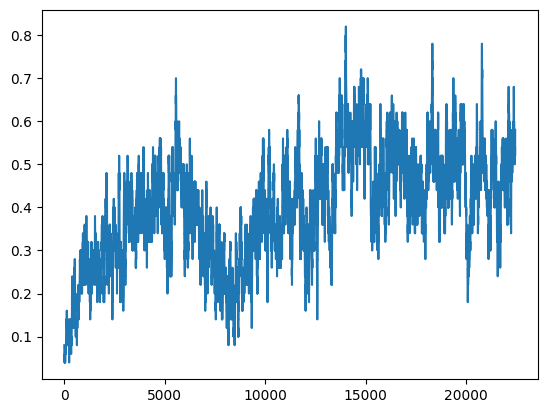

In [24]:
plt.plot(running_mean(np.asarray(trainer.logs["Scores"]) == 1, 50))